In [19]:
'''
PURPOSE: does label format match documentation, does a box land on real smoke, what does real smoke look like and could be mistaken for 
Is data skewed for different cameras? can images have more than one smoke box? 
Loading the data sets and visually confirming the splits
'''
import os # doesnt check dataset lib at all checks wtv is sitting in cache on disk 
os.environ['HF_DATASETS_OFFLINE'] = '1' # tells if issue is kernel relates vs network related

from datasets import load_dataset
ds = load_dataset('pyronear/pyro-sdis')
print (ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'annotations', 'image_name', 'partner', 'camera', 'date'],
        num_rows: 29537
    })
    val: Dataset({
        features: ['image', 'annotations', 'image_name', 'partner', 'camera', 'date'],
        num_rows: 4099
    })
})


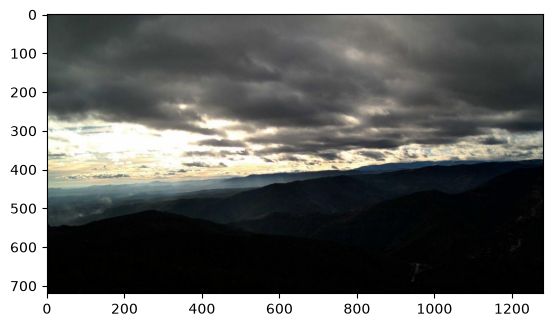

In [20]:
'''
testing display of images
'''
# matplotlib is plotting library 
# plt is module naming 
import matplotlib.pyplot as plt 
row = ds['train'][0] # first row of training split
plt.imshow(row['image']) # hands image to matplot lib and prepares the drawing
plt.show() # renders drawing on screen 

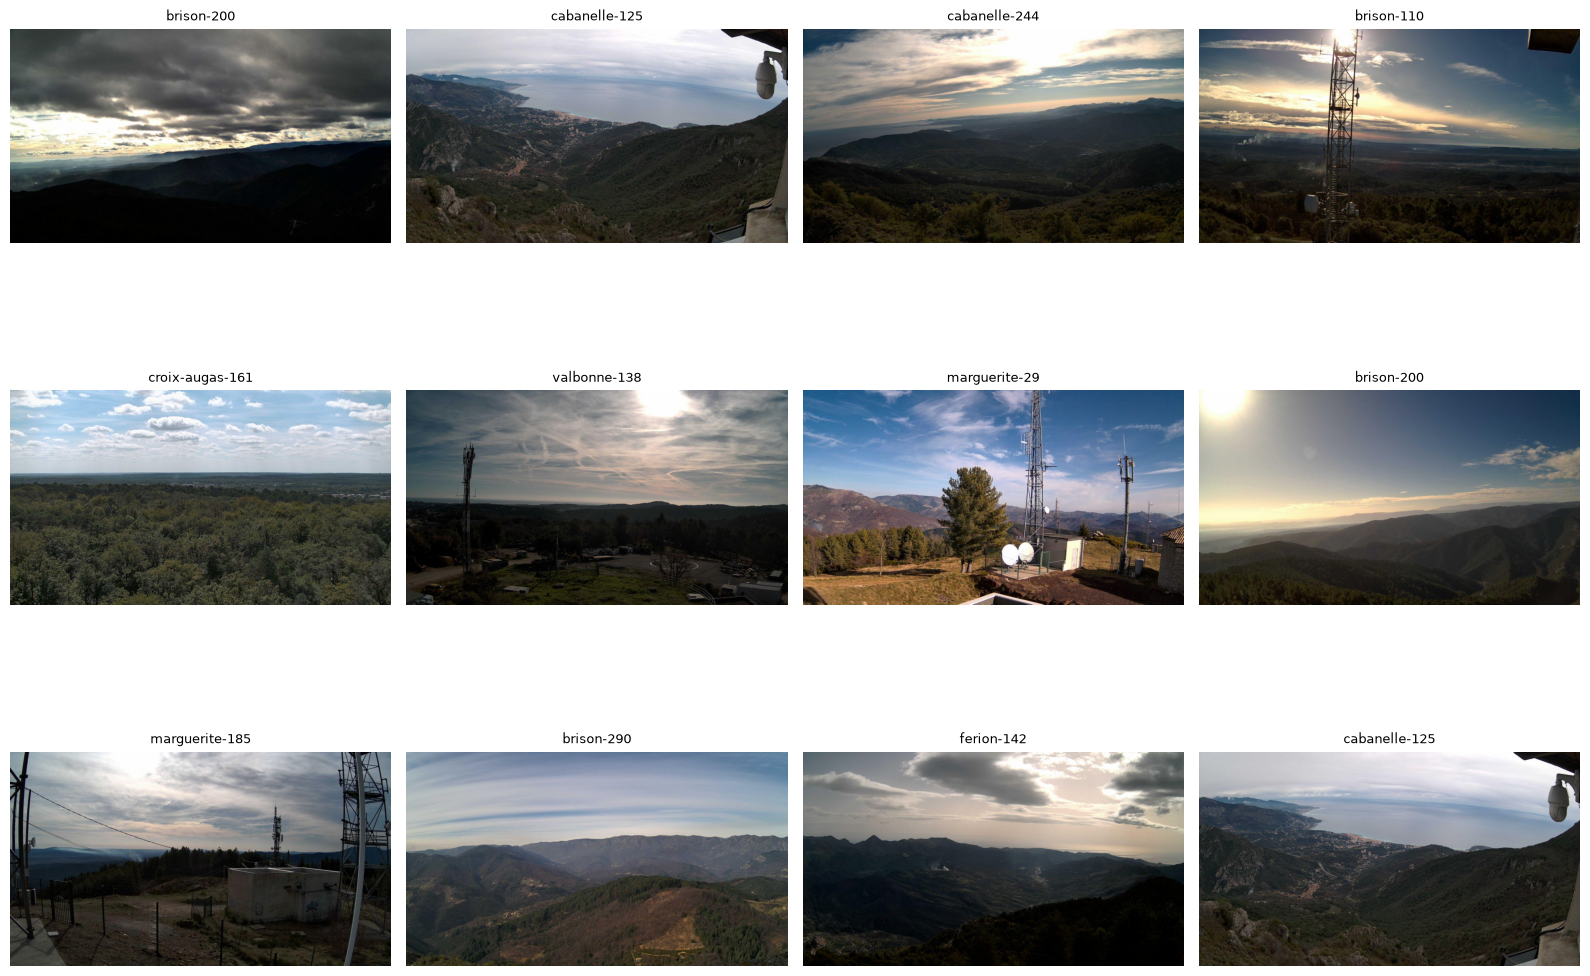

In [34]:
'''
grid of 12 images
'''
fig, axes = plt.subplots(3, 4, figsize=(16, 12)) # creates a grid  (3 rows * 4 columns
axes = axes.flatten() # flatten() reshapes it into one flat list of 12 slots so. i can index axes[0:12] wihtout worrying about rows and columns both 

for i in range(12):
    row = ds['train'][i] # gets the i-th image from the row of 12
    axes[i].imshow(row['image']) # draws image into slot i of grid 
    axes[i].set_title(row['camera'], fontsize=9) # labels each panel with the camera it belongs to 
    axes[i].axis('off') # turns off axis coordinates from matplotlib

plt.tight_layout() # adds enough spacing automatcally so nothing overlaps and gets cut off 

plt.show()

<class 'PIL.JpegImagePlugin.JpegImageFile'>
1 0.115638 0.357443 0.015700099999999995 0.013768000000000002
1 0.1915 0.348628 0.01583089999999998 0.009146729999999992
1.0 0.115638 0.357443 0.015700099999999995 0.013768000000000002
1.0 0.1915 0.348628 0.01583089999999998 0.009146729999999992


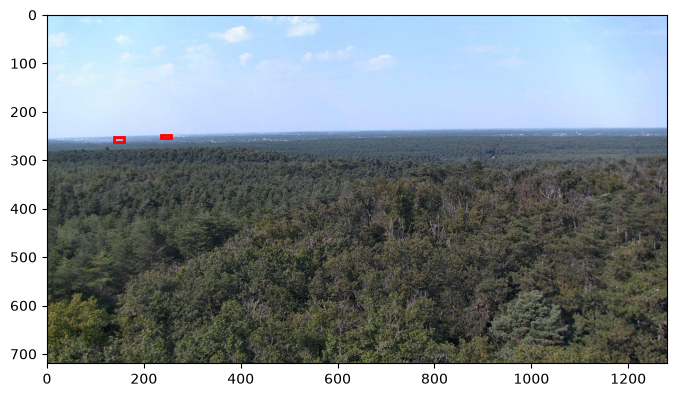

In [35]:
import matplotlib.patches as patches # imports graphing library in python and patches in the tool box for drawing shapes on top of an image

'''
drawing the annotation box
'''

row = ds['train'][12] # indexing first image in training ds so row becomes single training example
img = row['image'] # index's image from the row 
print(type(img)) # what kind of object?
# Pillow image so has mode size format and pixels image data available 
print(row['annotations']) # looks up value stored under 'annotations' key in that first image
# each line in annotations is smoke box 
# Pillow image so has mode size format and pixels image data available
# class_id = 1 , label box belongs too, cooridnates are percentages of where the center of the box is, last is the width and height percentages relevant to the box
img_w, img_h = img.size # to compute box sies
lines = row['annotations'].split('\n') # each entry is one complete box data and splits where there is whitespace 
# each line is a smoke box and is outputted as a string 
'''
Drawing each box need to find where the photo goes on the screen and where boxes get added?
''' 
fig, ax = plt.subplots(figsize =(8,6)) # fig is the entire image, ax is the plotting area as plt.subplots() returns 2 objects so we are creating the figure and plotting area
ax.imshow(img) # puts the img into the plotting area

for line in lines: # added cls bc python forces line.split() to give back 5 items 
    cls, x_center, y_center, width, height = [float(piece) for piece in line.split()]
    print(cls, x_center, y_center, width, height) # prints points out as floats not strings for mathematical operations
# fraction times image size = pixels 
    x_center_px = x_center * img_w 
    y_center_px = y_center * img_h 
    box_width_px = width * img_w 
    box_height_px = height * img_h 

    x0 = x_center_px - box_width_px / 2
    y0 = y_center_px - box_height_px / 2 

    rect = patches.Rectangle((x0, y0), box_width_px, box_height_px, 
    linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

plt.show()



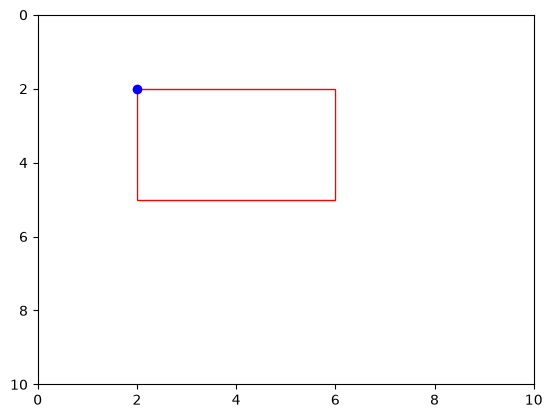

In [ ]:
'''''''
'''skiouhafouhsd'iu;vas;kfskmimport matplotlib.pyplot as plt
import matplotlib.patches as patches 

fig, ax = plt.subplots()
ax.set_xlim(0, 10) # fixes axis's to show values 0 - 10
ax.set_ylim(0, 10)
ax.invert_yaxis() # flips y axis so it counts downward bc images count rows from top down 

rect = patches.Rectangle((2,2), 4, 3, # anchored at 2,2 w 4 wide and 3 tall
edgecolor='red', facecolor='none') # draws nonthing need to add_patch() to apply 

ax.add_patch(rect) # attaches shape on plotting area 
ax.plot(2,2, 'bo') # blue circle at point 2,2 to see where coordinate lands in respect to rect
plt.show()


In [27]:
'''
every class_id that appears
label analysis script

'''

classes = set() # builds an empty set 
for i in range(500):
    for line in ds['train'][i]['annotations'].split('\n'):
        #nested loop outer goes through rows inner goes through boxes in a row as some rows can have more than one box
        if line.strip(): 
            classes.add(line.split()[0]) # list of 5 fields as strings indexing first field which is class_id only 
print(classes)




{'1'}


In [32]:
'''
counting images per camera
'''

from collections import Counter # class in collections module which takes a list and tallies how many times a value appears
# no dict as we would have to write a loop which checks if each key exists then increments it

camera_counts = Counter(ds['train']['camera']) # indexing camera column from training ds 
# counter() is a dict like object that maps each camera name to how many times it appears

print(len(camera_counts), 'unique cameras') # len() is on counter counts not total items so it counts how many unqiue cameras 
print(camera_counts.most_common(20)) # method on Counter that sorts count by highest to lowest
# returns list of (value, count) so the 10 busiest camera 

39 unique cameras
[('brison-200', 3960), ('brison-110', 3545), ('courmettes-212', 2527), ('courmettes-160', 2261), ('brison-290', 1761), ('marguerite-29', 1614), ('brison-20', 1310), ('courmettes-275', 1268), ('marguerite-339', 1226), ('ferion-142', 1187), ('marguerite-282', 1063), ('cabanelle-327', 1036), ('cabanelle-125', 781), ('ferion-287', 725), ('marguerite-185', 530), ('valbonne-349', 516), ('courmettes-80', 497), ('cabanelle-244', 495), ('croix-augas-59', 452), ('valbonne-67', 439)]
